<a href="https://colab.research.google.com/github/Pheonix1795/MDS_LAB/blob/main/MDS_WEEK(6%2C7%2C8).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Load the Dataset

We'll start by loading your housing dataset. Please ensure your `housing.csv` file is uploaded to your Colab environment or provide the correct path if it's located elsewhere.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from statsmodels.graphics.gofplots import qqplot

# Load the selected California Housing test dataset
try:
    df = pd.read_csv('/content/sample_data/california_housing_test.csv')
    print("Dataset loaded successfully!")
    print(f"Shape of the dataset: {df.shape}")
except Exception as e:
    print(f"Error loading dataset: {e}")
    df = None

Dataset loaded successfully!
Shape of the dataset: (3000, 9)


### Data Inspection

Let's take a quick look at the data to understand its structure and content.

In [8]:
if df is not None:
    display(df.head())
    print("\nDataset Info:")
    df.info()
    print("\nMissing values:")
    display(df.isnull().sum()[df.isnull().sum() > 0])

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.05,37.37,27.0,3885.0,661.0,1537.0,606.0,6.6085,344700.0
1,-118.30,34.26,43.0,1510.0,310.0,809.0,277.0,3.5990,176500.0
2,-117.81,33.78,27.0,3589.0,507.0,1484.0,495.0,5.7934,270500.0
3,-118.36,33.82,28.0,67.0,15.0,49.0,11.0,6.1359,330000.0
4,-119.67,36.33,19.0,1241.0,244.0,850.0,237.0,2.9375,81700.0



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           3000 non-null   float64
 1   latitude            3000 non-null   float64
 2   housing_median_age  3000 non-null   float64
 3   total_rooms         3000 non-null   float64
 4   total_bedrooms      3000 non-null   float64
 5   population          3000 non-null   float64
 6   households          3000 non-null   float64
 7   median_income       3000 non-null   float64
 8   median_house_value  3000 non-null   float64
dtypes: float64(9)
memory usage: 211.1 KB

Missing values:


,0


### Simple Linear Regression Setup

For simple linear regression, we need to choose one independent variable (feature) and one dependent variable (target). Please replace `'YOUR_FEATURE_COLUMN'` and `'YOUR_TARGET_COLUMN'` with the actual column names from your dataset.

For example, if you want to predict 'median_house_value' using 'median_income', you would set `feature_column = 'median_income'` and `target_column = 'median_house_value'`.

In [9]:
if df is not None:
    # Using 'median_income' to predict 'median_house_value' from the CSV dataset
    feature_column = 'median_income'
    target_column = 'median_house_value'

    # Check if the chosen columns exist
    if feature_column not in df.columns or target_column not in df.columns:
        print(f"Error: One or both of the chosen columns ('{feature_column}', '{target_column}') do not exist in the dataset.")
    else:
        # Drop rows with missing values in the selected columns
        df_filtered = df.dropna(subset=[feature_column, target_column])

        X = df_filtered[[feature_column]]
        y = df_filtered[target_column]

        # Split data into training and testing sets
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

        # Initialize and train the Simple Linear Regression model
        model = LinearRegression()
        model.fit(X_train, y_train)

        print("\nSimple Linear Regression Model Trained.")
        print(f"Intercept: {model.intercept_:.2f}")
        print(f"Coefficient for {feature_column}: {model.coef_[0]:.2f}")

        # Make predictions on the test set
        y_pred = model.predict(X_test)

        # Calculate residuals
        residuals = y_test - y_pred


Simple Linear Regression Model Trained.
Intercept: 50847.82
Coefficient for median_income: 40940.61


### Residual Analysis and Plots

Now, let's perform residual analysis to check the assumptions of linear regression, such as linearity, independence, normality, and homoscedasticity of residuals.

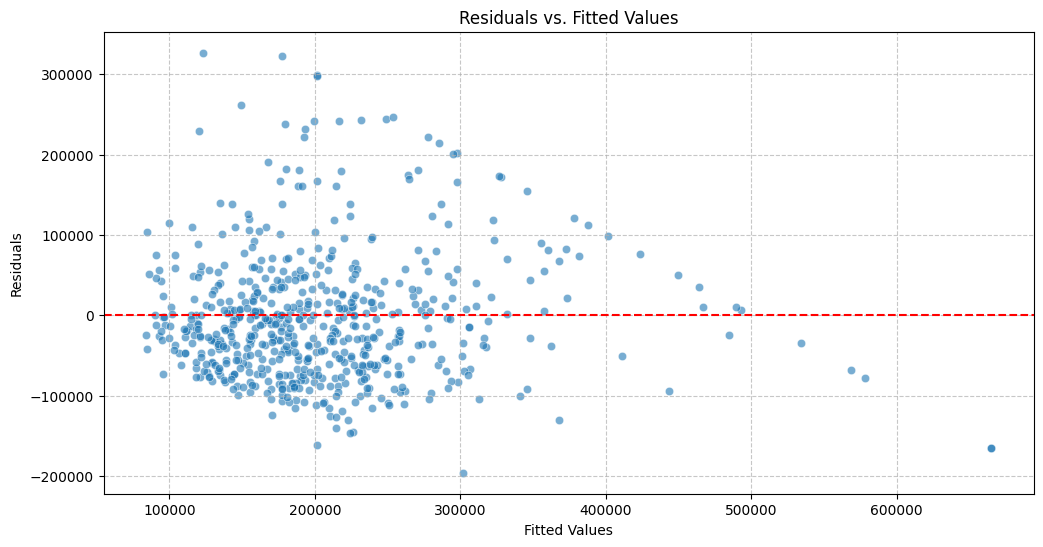

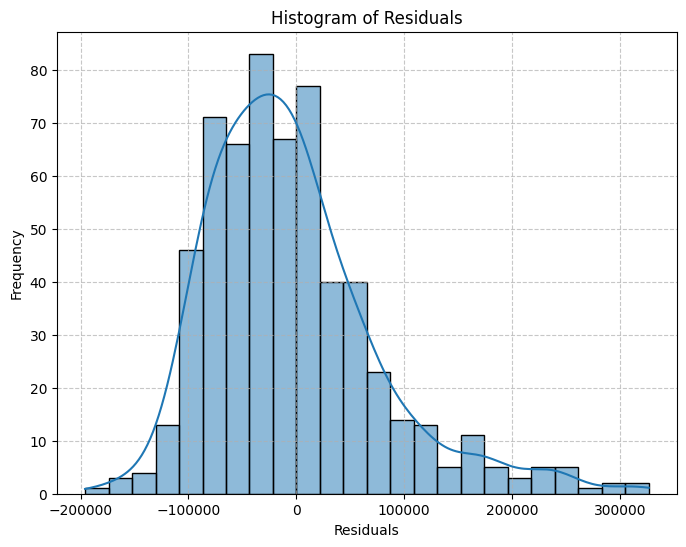

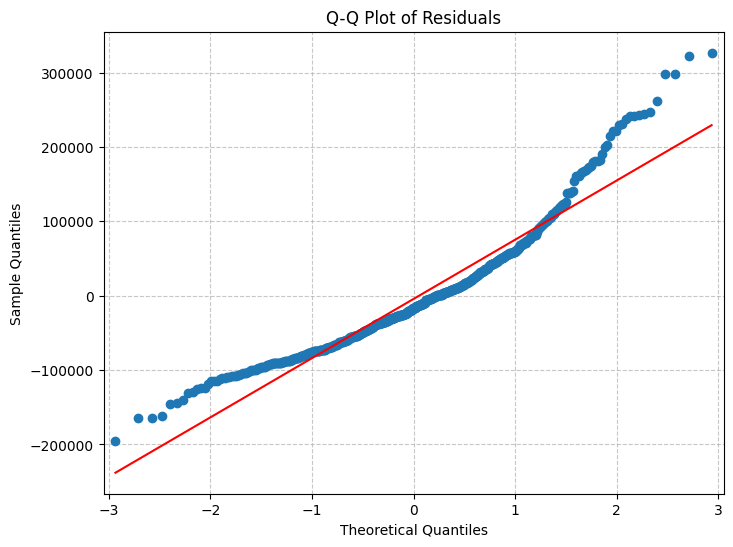

Residual analysis plots generated. Interpret these plots to assess model assumptions:
  - **Residuals vs. Fitted Values**: Look for a random scatter around zero. A pattern (e.g., cone shape) indicates heteroscedasticity.
  - **Histogram of Residuals**: Should ideally be bell-shaped and centered around zero, suggesting normality.
  - **Q-Q Plot of Residuals**: Points should fall approximately along the 45-degree line for normal distribution.


In [10]:
if df is not None and 'model' in locals(): # Ensure model was successfully trained
    # 1. Residuals vs. Fitted Values Plot (Homoscedasticity Check)
    plt.figure(figsize=(12, 6))
    sns.scatterplot(x=y_pred, y=residuals, alpha=0.6)
    plt.axhline(y=0, color='r', linestyle='--')
    plt.title('Residuals vs. Fitted Values')
    plt.xlabel('Fitted Values')
    plt.ylabel('Residuals')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

    # 2. Histogram of Residuals (Normality Check)
    plt.figure(figsize=(8, 6))
    sns.histplot(residuals, kde=True)
    plt.title('Histogram of Residuals')
    plt.xlabel('Residuals')
    plt.ylabel('Frequency')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

    # 3. Q-Q Plot of Residuals (Normality Check)
    plt.figure(figsize=(8, 6))
    qqplot(residuals, line='s', ax=plt.gca())
    plt.title('Q-Q Plot of Residuals')
    plt.xlabel('Theoretical Quantiles')
    plt.ylabel('Sample Quantiles')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

    print("Residual analysis plots generated. Interpret these plots to assess model assumptions:")
    print("  - **Residuals vs. Fitted Values**: Look for a random scatter around zero. A pattern (e.g., cone shape) indicates heteroscedasticity.")
    print("  - **Histogram of Residuals**: Should ideally be bell-shaped and centered around zero, suggesting normality.")
    print("  - **Q-Q Plot of Residuals**: Points should fall approximately along the 45-degree line for normal distribution.")
else:
    print("Could not perform residual analysis. Please ensure the dataset was loaded and columns were correctly selected for model training.")

### Model Performance Evaluation

To quantitatively evaluate how well our simple linear regression model fits the housing data, we can calculate standard regression metrics on both the training and testing sets:
- **Mean Absolute Error (MAE):** The average of the absolute differences between predictions and actual values.
- **Mean Squared Error (MSE):** The average of the squared differences (penalizes larger errors more).
- **Root Mean Squared Error (RMSE):** The square root of MSE, representing the error in the same units as the target variable.
- **R-squared ($R^2$):** The proportion of variance in the dependent variable that is predictable from the independent variable.

In [11]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

if 'model' in locals():
    # Get predictions for both training and testing sets
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Calculate metrics for Training Set
    mae_train = mean_absolute_error(y_train, y_train_pred)
    mse_train = mean_squared_error(y_train, y_train_pred)
    rmse_train = np.sqrt(mse_train)
    r2_train = r2_score(y_train, y_train_pred)

    # Calculate metrics for Testing Set
    mae_test = mean_absolute_error(y_test, y_test_pred)
    mse_test = mean_squared_error(y_test, y_test_pred)
    rmse_test = np.sqrt(mse_test)
    r2_test = r2_score(y_test, y_test_pred)

    # Print the results in a formatted layout
    print("================ MODEL PERFORMANCE ================")
    print(f"{'Metric':<20} | {'Training Set':<15} | {'Testing Set':<15}")
    print("-" * 58)
    print(f"{'MAE':<20} | {mae_train:<15.2f} | {mae_test:<15.2f}")
    print(f"{'MSE':<20} | {mse_train:<15.2f} | {mse_test:<15.2f}")
    print(f"{'RMSE':<20} | {rmse_train:<15.2f} | {rmse_test:<15.2f}")
    print(f"{'R2 Score':<20} | {r2_train:<15.4f} | {r2_test:<15.4f}")
    print("===================================================")
else:
    print("Please ensure the model has been trained before executing performance metrics.")

================ MODEL PERFORMANCE ================
Metric               | Training Set    | Testing Set    
----------------------------------------------------------
MAE                  | 63478.66        | 60123.48       
MSE                  | 7166151535.55   | 6355701945.13  
RMSE                 | 84653.12        | 79722.66       
R2 Score             | 0.4415          | 0.4953         
